## Section 1: Import Required Libraries

In [11]:
# Data handling & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve
)

# Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import joblib

## Section 2: Load and Split the Cleaned Dataset

In [12]:
# Ensure model and output directories exist
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

# Load cleaned data
df = pd.read_csv("../data/clean_credit_data.csv")

# Separate features and target
X = df.drop("SeriousDlqin2yrs", axis=1)
y = df["SeriousDlqin2yrs"]

# Split the data into training and test sets with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

## Section 3: After Handling Class Imbalance with SMOTE produce a report

In [13]:
# Apply SMOTE to balance the minority class
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

# Print class distributions before and after SMOTE
print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_resampled))

Before SMOTE: [111979   8021]
After SMOTE: [111979 111979]


## Section 4: Train and Evaluate Base Models

In [14]:
# Initialize models
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

# Train models on balanced data
logreg.fit(X_resampled, y_resampled)
rf.fit(X_resampled, y_resampled)

# Make predictions on test data
y_pred_lr = logreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluate Logistic Regression
print("📊 Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1]))

# Evaluate Random Forest
print("🌲 Random Forest")
print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

📊 Logistic Regression
              precision    recall  f1-score   support

           0       0.97      0.76      0.85     27995
           1       0.17      0.69      0.27      2005

    accuracy                           0.76     30000
   macro avg       0.57      0.72      0.56     30000
weighted avg       0.92      0.76      0.81     30000

ROC AUC: 0.7950220893559992
🌲 Random Forest
              precision    recall  f1-score   support

           0       0.95      0.96      0.95     27995
           1       0.35      0.34      0.35      2005

    accuracy                           0.91     30000
   macro avg       0.65      0.65      0.65     30000
weighted avg       0.91      0.91      0.91     30000

ROC AUC: 0.8249391791106268


## Section 5: Visualize Confusion Matrices

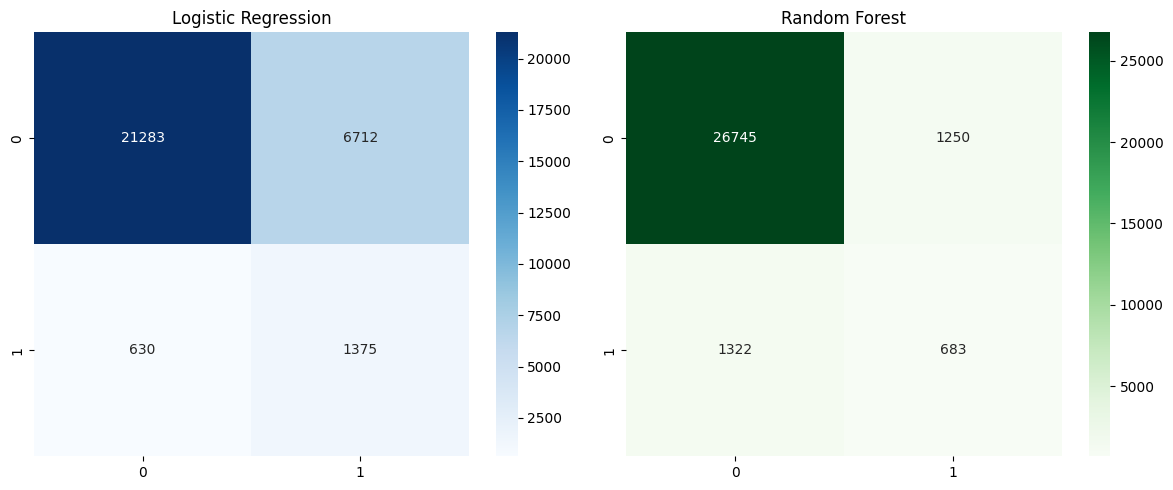

In [15]:
# Compare confusion matrices for both models
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression")

plt.subplot(1, 2, 2)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest")

plt.tight_layout()
plt.show()

## Section 6: Feature Importance from Random Forest

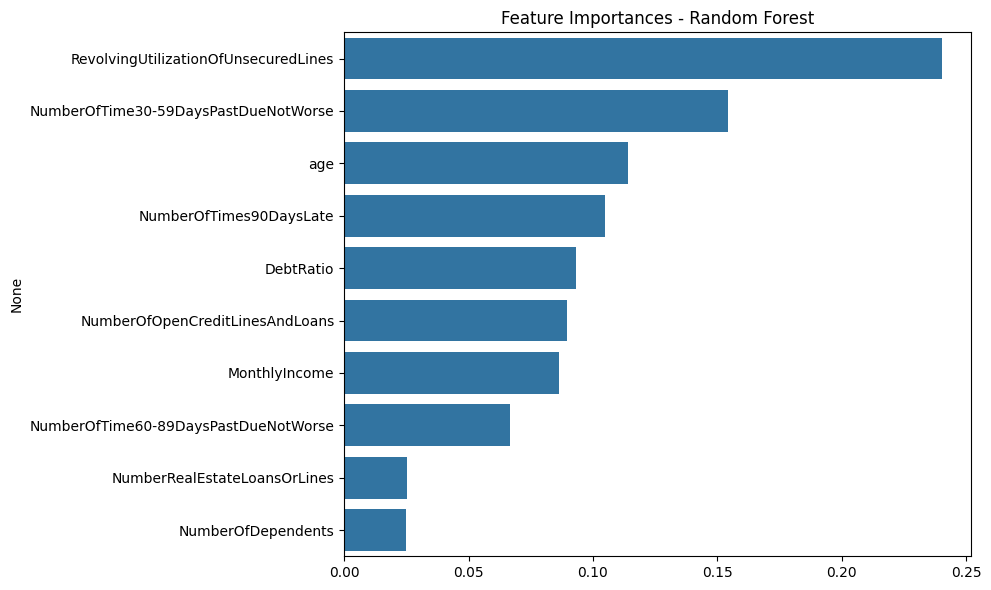

In [16]:
# Display and save top features used by the Random Forest model
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances - Random Forest")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png")
plt.show()

## Section 7: Tune Random Forest with GridSearchCV

In [17]:
# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'min_samples_split': [2]
}

# Perform GridSearch with cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearch to resampled training data
grid_search.fit(X_resampled, y_resampled)
best_model = grid_search.best_estimator_

# Show best parameters
print("✅ Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
✅ Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## Section 8: Evaluate Tuned Best Model

In [18]:
# Evaluate the best model on the test set
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("📊 Best Model Performance:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

📊 Best Model Performance:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92     27995
           1       0.26      0.65      0.37      2005

    accuracy                           0.85     30000
   macro avg       0.62      0.76      0.65     30000
weighted avg       0.92      0.85      0.88     30000

ROC AUC: 0.8556315676249633


## Section 9: Save the Best Model and Report

In [19]:
# Save the best model to disk
joblib.dump(best_model, "models/best_model.pkl")

# Save classification report to text file
with open("outputs/model_report.txt", "w") as f:
    f.write("Best Model: RandomForestClassifier\n")
    f.write("ROC AUC: {:.4f}\n".format(roc_auc_score(y_test, y_proba)))
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_test, y_pred))

## Section 10: Plot Precision-Recall Curve

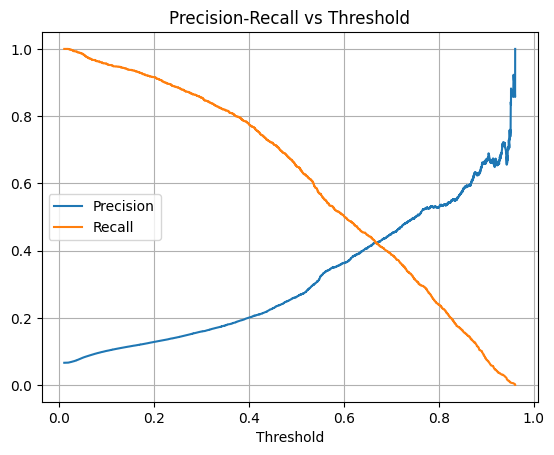

In [20]:
# Plot precision-recall tradeoff for different thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()